XGBoost versão: 3.3.0

Shape original: (81881, 84)

✅ Clusters criados com sucesso (K=6)
Removendo variáveis sujas/leakage: ['score_propensao_churn', 'cluster_sugerido_crm', 'data_primeira_apolice', 'data_nascimento', 'renovacoes_consecutivas']
Shape após limpeza: (81881, 79)

TREINAMENTO XGBOOST OTIMIZADO (5-FOLD CV)
Fold 1 | Melhor Árvore:  247 | AUC: 0.8386
Fold 2 | Melhor Árvore:  232 | AUC: 0.8314
Fold 3 | Melhor Árvore:  341 | AUC: 0.8428
Fold 4 | Melhor Árvore:  132 | AUC: 0.8270
Fold 5 | Melhor Árvore:  247 | AUC: 0.8262

➡️ AUC Médio de Validação (OOF): 0.8320

RESULTADO FINAL NA BASE DE TESTE (SIMULAÇÃO KAGGLE)
ROC-AUC Final      : 0.8268 🏆
Avg Precision      : 0.4300

Relatório de Classificação:
              precision    recall  f1-score   support

   Não-churn       0.89      0.99      0.94     14395
       Churn       0.66      0.08      0.15      1982

    accuracy                           0.88     16377
   macro avg       0.77      0.54      0.54     16377
weighted avg

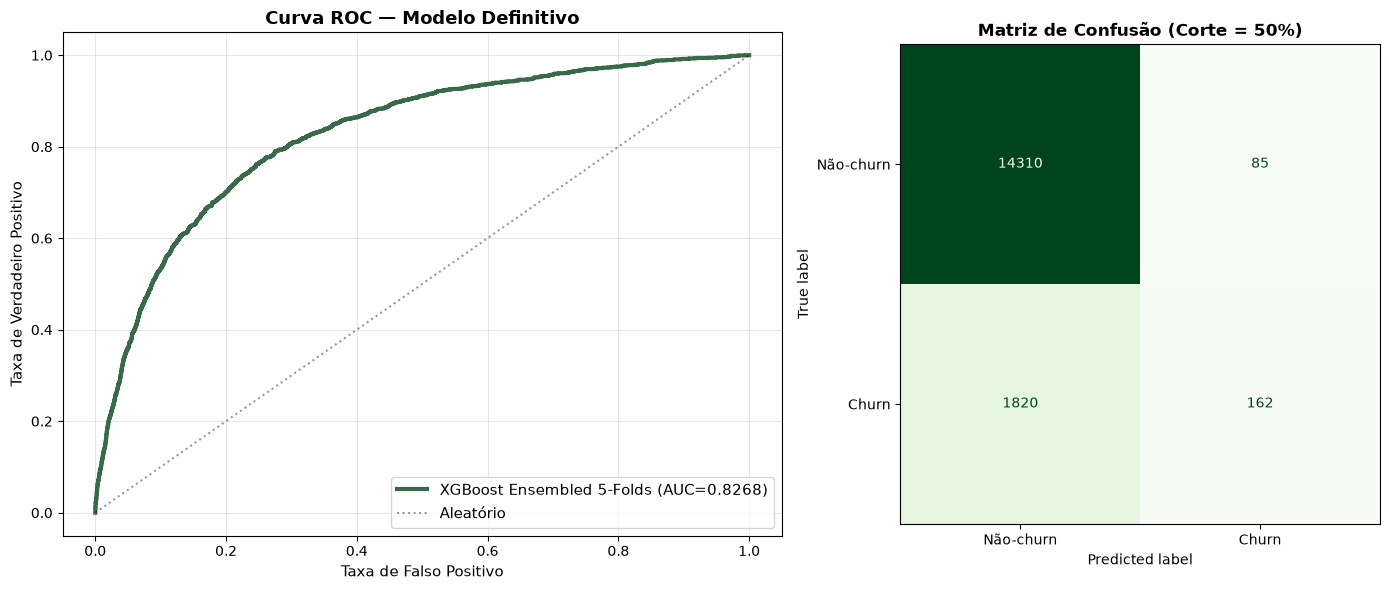

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

import xgboost as xgb

# ==========================================
# 1. CONFIGURAÇÕES VISUAIS E VARIÁVEIS
# ==========================================
PRT_NAVY  = "#19284F"
PRT_GREEN = "#39694B"
PRT_GRAY  = "#737C8A"
RANDOM_STATE = 42

print(f"XGBoost versão: {xgb.__version__}\n")

# ==========================================
# 2. CARREGAMENTO E CRIAÇÃO DE CLUSTERS
# ==========================================
df = pd.read_csv("../bases/tabelas_unificadas/Base_Unificada_Tratada.csv")
print(f"Shape original: {df.shape}")

FEATURES_CLUSTER = [
    "tempo_cliente_dias", "num_apolices_ativas", "num_produtos_contratados",
    "desconto_aplicado_pct", "indice_relacionamento", "num_apolices_basica",
    "satisfacao_nps", "tipo_cobertura_basica", "estado_civil", "tipo_cobertura_premium",
    "tem_filhos", "renda_anual", "qtd_dependentes", "valor_imovel",
    "num_apolices_premium", "valor_cobertura_total", "idade", "num_apolices_padrao",
    "score_engajamento_digital", "pagamento_em_dia", "num_reclamacoes_12m",
    "num_acessos_app_mes", "possui_imovel", "tipo_cobertura_padrao",
    "valor_premio_anual", "franquia_media"
]

K_FINAL = 6 

X_c = df[FEATURES_CLUSTER].copy()
imp_c = SimpleImputer(strategy="median")
X_c_scaled = StandardScaler().fit_transform(imp_c.fit_transform(X_c))

kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_c_scaled)

print(f"\n✅ Clusters criados com sucesso (K={K_FINAL})")

# ==========================================
# 3. LIMPEZA DE LEAKAGE E MULTICOLINEARIDADE
# ==========================================
colunas_remover = ["score_propensao_churn", "cluster_sugerido_crm", 
                   "data_primeira_apolice", "data_nascimento", "renovacoes_consecutivas"]

presentes = [c for c in colunas_remover if c in df.columns]
if presentes:
    df = df.drop(columns=presentes)
    print(f"Removendo variáveis sujas/leakage: {presentes}")

# Separa Target (y) e Features (X)
target = "churned"
X = df.drop(columns=[target])
y = df[target]

print(f"Shape após limpeza: {X.shape}\n")

# Imputação de nulos para o modelo
imputer_final = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer_final.fit_transform(X), columns=X.columns)

# ==========================================
# 4. SPLIT LOCAL (80% TREINO / 20% TESTE)
# ==========================================
# O Teste (20%) fica intocável para simularmos o Kaggle no final
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# ==========================================
# 5. A MÁQUINA DE VENCER: STRATIFIED K-FOLD
# ==========================================
# Parâmetros otimizados para AUC (Devagar e Sempre, sem distorção de peso)
xgb_params = {
    "n_estimators": 5000,          # Subimos drasticamente as árvores
    "max_depth": 5,
    "learning_rate": 0.01,         # Aprendizado mais lento e refinado
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": 1.0,       # Removido o peso para não sujar o ranking do AUC
    "tree_method": "hist",
    "eval_metric": "auc",
    "early_stopping_rounds": 50,   # Para automaticamente se parar de melhorar
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# Preparamos o K-Fold de 5 divisões
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Arrays para guardar as previsões e lista de modelos
oof_preds = np.zeros(len(X_train)) # Previsões fora-do-fold (validação)
test_preds = np.zeros(len(X_test)) # Previsões acumuladas do teste
modelos_treinados = []

print(f"{'='*55}")
print(f"TREINAMENTO XGBOOST OTIMIZADO ({N_FOLDS}-FOLD CV)")
print(f"{'='*55}")

# Loop de treinamento dos 5 modelos
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    # Separa os dados do fold atual
    X_f_train, y_f_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_f_val, y_f_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    # Inicia o modelo
    clf = xgb.XGBClassifier(**xgb_params)
    
    # Treina o modelo assistindo a base de validação do fold
    clf.fit(
        X_f_train, y_f_train,
        eval_set=[(X_f_val, y_f_val)],
        verbose=False # Deixando False para não poluir a tela com 5000 linhas
    )
    
    # 1. Guarda a previsão de validação (OOF - Out of Fold)
    y_val_proba = clf.predict_proba(X_f_val)[:, 1]
    oof_preds[val_idx] = y_val_proba
    
    # 2. Faz a previsão na NOSSA BASE DE TESTE (20%) e soma na média
    test_preds += clf.predict_proba(X_test)[:, 1] / N_FOLDS
    
    # Guarda o modelo treinado na lista (vamos usar esses 5 pro Kaggle depois)
    modelos_treinados.append(clf)
    
    # Calcula e exibe o AUC local deste Fold
    fold_auc = roc_auc_score(y_f_val, y_val_proba)
    print(f"Fold {fold+1} | Melhor Árvore: {clf.best_iteration:4d} | AUC: {fold_auc:.4f}")

# Calcula o AUC geral do Treino (usando as validações cruzadas)
auc_treino_cv = roc_auc_score(y_train, oof_preds)
print(f"\n➡️ AUC Médio de Validação (OOF): {auc_treino_cv:.4f}")

# ==========================================
# 6. AVALIAÇÃO NA BASE DE TESTE LOCAL (20%)
# ==========================================
# Como é K-Fold, a nossa previsão final é a Média dos 5 modelos
auc_teste = roc_auc_score(y_test, test_preds)
avg_precision = average_precision_score(y_test, test_preds)

# Para a Matriz de Confusão, convertemos a probabilidade para 0 ou 1 (corte em 0.5)
y_pred_binario = (test_preds >= 0.5).astype(int)

print(f"\n{'='*55}")
print("RESULTADO FINAL NA BASE DE TESTE (SIMULAÇÃO KAGGLE)")
print(f"{'='*55}")
print(f"ROC-AUC Final      : {auc_teste:.4f} 🏆")
print(f"Avg Precision      : {avg_precision:.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_binario, target_names=["Não-churn", "Churn"]))

# ==========================================
# 7. VISUALIZAÇÃO DOS RESULTADOS
# ==========================================
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(1, 2, width_ratios=[1.5, 1])

# --- Gráfico 1: Curva ROC ---
ax0 = fig.add_subplot(gs[0])
fpr, tpr, _ = roc_curve(y_test, test_preds)
ax0.plot(fpr, tpr, label=f"XGBoost Ensembled 5-Folds (AUC={auc_teste:.4f})", linewidth=3, color=PRT_GREEN)
ax0.plot([0, 1], [0, 1], linestyle=":", color="black", alpha=0.4, label="Aleatório")
ax0.set_xlabel("Taxa de Falso Positivo", fontsize=11)
ax0.set_ylabel("Taxa de Verdadeiro Positivo", fontsize=11)
ax0.set_title("Curva ROC — Modelo Definitivo", fontsize=13, fontweight="bold")
ax0.legend(loc="lower right", fontsize=11)
ax0.grid(True, alpha=0.3)

# --- Gráfico 2: Matriz de Confusão ---
ax1 = fig.add_subplot(gs[1])
cm = confusion_matrix(y_test, y_pred_binario)
disp = ConfusionMatrixDisplay(cm, display_labels=["Não-churn", "Churn"])
disp.plot(ax=ax1, cmap="Greens", colorbar=False)
ax1.set_title("Matriz de Confusão (Corte = 50%)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

print("Gerando o arquivo de submissão oficial para o Kaggle...")

# 1. Carrega a base oficial de teste do Kaggle (a base cega, sem as respostas de churn)
df_teste_real = pd.read_csv('../bases/bases_kaggle/Base_Unificada_Kaggle_Outer.csv') 

# 2. Captura os IDs originais correspondentes ao 'id_cliente' para montar o arquivo final
# Se na sua base o nome for diferente, ajuste entre as aspas
coluna_id_orig = 'id_cliente' if 'id_cliente' in df_teste_real.columns else df_teste_real.columns[0]
ids_clientes = df_teste_real[coluna_id_orig].copy()

# =========================================================================
# NOTA: Lembre-se de rodar aqui as suas funções de limpeza e padronização 
# na tabela 'df_teste_real' para que ela fique com as mesmas colunas do treino!
# Exemplo: df_teste_tratado = limpar_tabela_marketing(df_teste_real)
# =========================================================================

# 3. Garante que a ordem e o nome de todas as colunas sejam idênticos ao X_train
# Isso evita o erro de colunas faltantes ou fora de ordem no XGBoost
df_teste_pronto = df_teste_real.reindex(columns=X_train.columns, fill_value=0)

# 4. Faz a predição combinada tirando a média das probabilidades dos 5 modelos
probabilidades_finais = np.zeros(len(df_teste_pronto))

for modelo in modelos_treinados:
    probabilidades_finais += modelo.predict_proba(df_teste_pronto)[:, 1] / len(modelos_treinados)

# 5. Monta o DataFrame estruturado no padrão exato exigido pelo desafio
submissao_kaggle = pd.DataFrame({
    'Id': ids_clientes,
    'churn_prob': probabilidades_finais
})

# 6. Salva o arquivo final em formato CSV
# O parâmetro index=False é OBRIGATÓRIO para o Pandas não criar uma coluna de numeração extra
submissao_kaggle.to_csv('submissao_final_xgboost.csv', index=False)

print("\n✅ Arquivo 'submissao_final_xgboost.csv' gerado com sucesso!")
print("\nPrimeiras linhas do arquivo para validação visual:")
print(submissao_kaggle.head())

Gerando o arquivo de submissão oficial para o Kaggle...


FileNotFoundError: [Errno 2] No such file or directory: 'bases/bases_kaggle/Base_Unificada_Kaggle_Outer.csv'